Cell 1 – Imports and configuration

In [ ]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from datetime import datetime

# Inkscape config (for EMF export)
ENABLE_EMF_EXPORT = True          # Set False to disable EMF export
INKSCAPE_EXE = r"C:\Program Files\Inkscape\bin\inkscape.exe"   # Adjust to your system


rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 1.2
rcParams['lines.linewidth'] = 2.0
rcParams['figure.dpi'] = 150               

print("✅ Setup complete. Ready to go.\n")


✅ Setup complete. Ready to go.



Cell 2 – Function that computes the DTFT of the rectangular pulse

In [2]:
def dtft_square_pulse(omega, N1):
    """
    Compute the DTFT of a discrete square pulse of length 2*N1+1.
    X(e^{j omega}) = sin(omega * (N1 + 0.5)) / sin(omega / 2)
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        numerator = np.sin(omega * (N1 + 0.5))
        denominator = np.sin(omega / 2)
        X = np.where(np.abs(denominator) < 1e-12, 2*N1+1, numerator / denominator)
    return X

print("✅ DTFT function defined.\n")

✅ DTFT function defined.



Cell 3 – Combined DTFT plot (all N₁ on one figure)

⏳ Starting combined DTFT plot ...
📈 Computing DTFT values for each N₁ ...
✏️ Adding annotations and styling ...
💾 Saving combined PNG ...
✔️  Saved PNG: plots\combined_dtft_20260511_145405.png
💾 Saving combined SVG ...
✔️  Saved SVG: plots\combined_dtft_20260511_145405.svg
🔄 Attempting combined EMF via Inkscape ...
✔️  Saved EMF: plots\combined_dtft_20260511_145405.emf


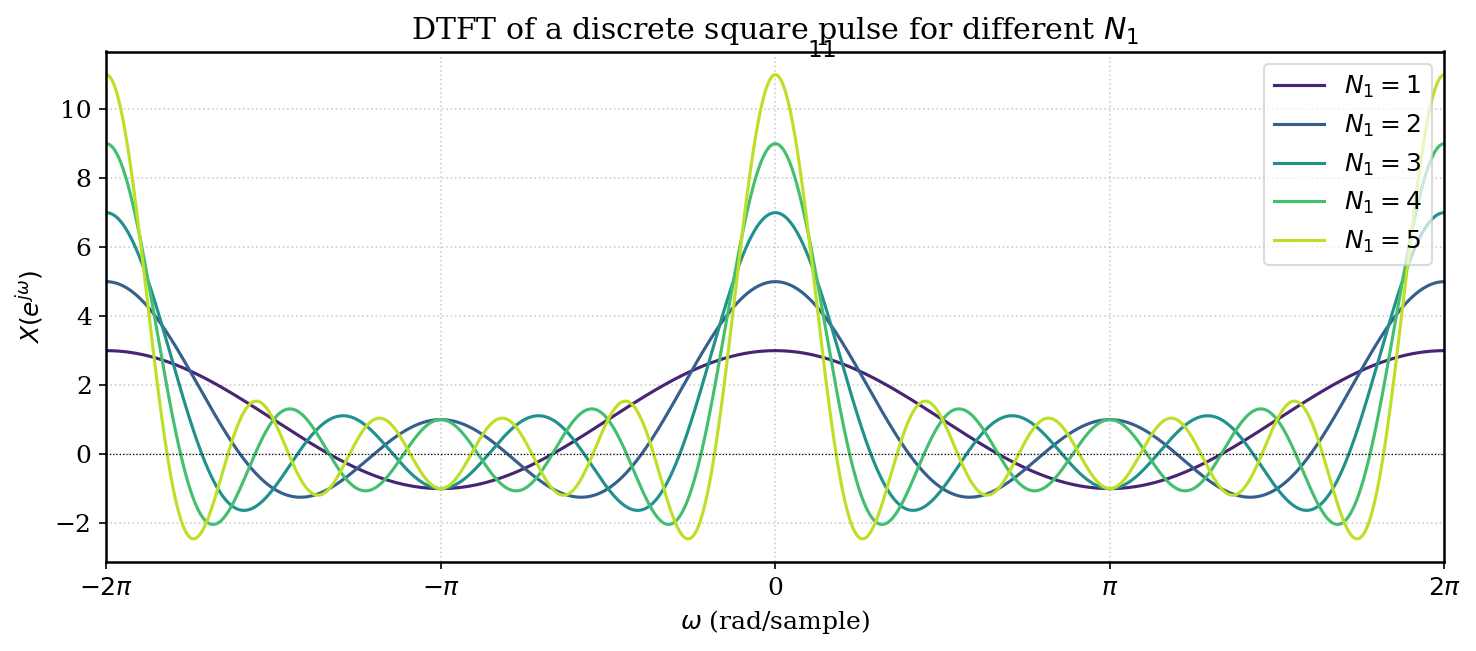

✅ Combined plot finished.



In [3]:
# ==================================================
#  Choose your N1 values here
# ==================================================
N1_values = [1, 2, 3, 4, 5]   
# ==================================================


if not N1_values:
    raise ValueError("N1_values must contain at least one integer.")

print("⏳ Starting combined DTFT plot ...")

# Frequency axis: full range from -2π to 2π 
omega = np.linspace(-2*np.pi, 2*np.pi, 2000)

print("📈 Computing DTFT values for each N₁ ...")
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(N1_values)))
for N1, color in zip(N1_values, colors):
    X = dtft_square_pulse(omega, N1)
    ax.plot(omega, X, label=f'$N_1 = {N1}$', color=color, linewidth=1.5)

print("✏️ Adding annotations and styling ...")
N1_max = max(N1_values)
ax.annotate(
    f'${2*N1_max+1}$',
    xy=(0, 2*N1_max+1),
    xytext=(0.3, 2*N1_max+1 + 0.5),
    ha='left',
    fontsize=11,
    color='black'
)

ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax.set_xlabel(r'$\omega$ (rad/sample)')
ax.set_ylabel(r'$X(e^{j\omega})$')
ax.set_title('DTFT of a discrete square pulse for different $N_1$')
ax.legend(loc='upper right', framealpha=0.7)

# x‑axis ticks: -2π, -π, 0, π, 2π
xticks = [-2*np.pi, -np.pi, 0, np.pi, 2*np.pi]
xticklabels = [r'$-2\pi$', r'$-\pi$', '0', r'$\pi$', r'$2\pi$']
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Export combined plot
export_dir = r"plots"  #### HERE U CAN TO ADJUST THE EXPORT DIRECTORY!! 
os.makedirs(export_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

combined_svg = os.path.join(export_dir, f"combined_dtft_{timestamp}.svg")
combined_png = os.path.join(export_dir, f"combined_dtft_{timestamp}.png")
combined_emf = os.path.join(export_dir, f"combined_dtft_{timestamp}.emf")

print("💾 Saving combined PNG ...")
fig.savefig(combined_png, dpi=300)
print("✔️  Saved PNG:", combined_png)

print("💾 Saving combined SVG ...")
fig.savefig(combined_svg)
print("✔️  Saved SVG:", combined_svg)

if ENABLE_EMF_EXPORT:
    print("🔄 Attempting combined EMF via Inkscape ...")
    try:
        if not os.path.isfile(INKSCAPE_EXE):
            raise FileNotFoundError(f"Inkscape not found at: {INKSCAPE_EXE}")
        cmd = [INKSCAPE_EXE, combined_svg, "--export-type=emf", f"--export-filename={combined_emf}"]
        subprocess.run(cmd, check=True)
        print("✔️  Saved EMF:", combined_emf)
    except Exception as e:
        print(f"[WARN] Combined EMF export failed: {e}")

plt.show()
print("✅ Combined plot finished.\n")

Cell 4 – Time‑domain rectangular pulse plot for each N₁

⏳ Generating time‑domain rectangular pulse plots for each N₁ ...

⏺ N₁ = 1
   💾 Saving PNG ...
   ✔️  PNG: plots\rect_n1_1_20260511_145446.png
   💾 Saving SVG ...
   ✔️  SVG: plots\rect_n1_1_20260511_145446.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\rect_n1_1_20260511_145446.emf


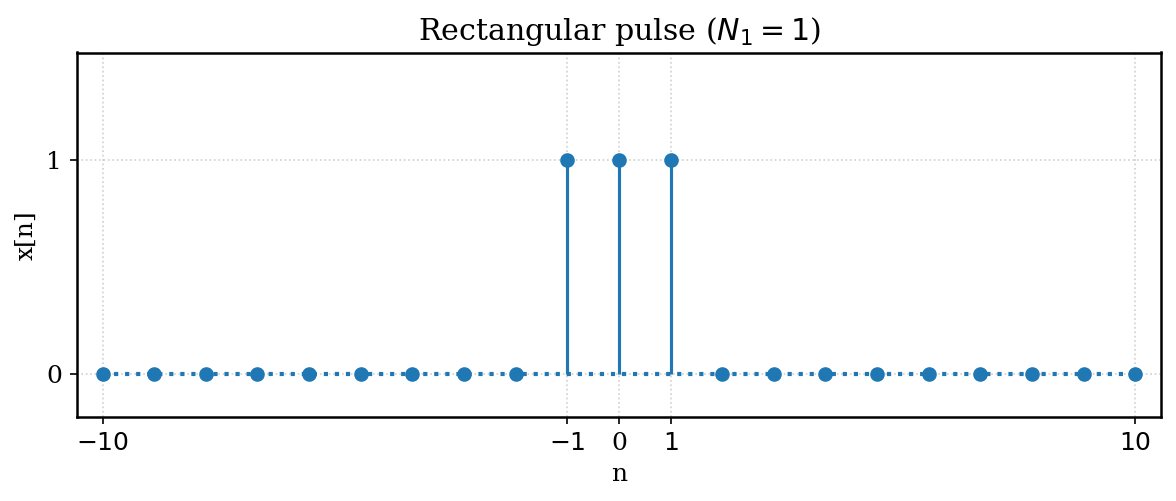


⏺ N₁ = 2
   💾 Saving PNG ...
   ✔️  PNG: plots\rect_n1_2_20260511_145448.png
   💾 Saving SVG ...
   ✔️  SVG: plots\rect_n1_2_20260511_145448.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\rect_n1_2_20260511_145448.emf


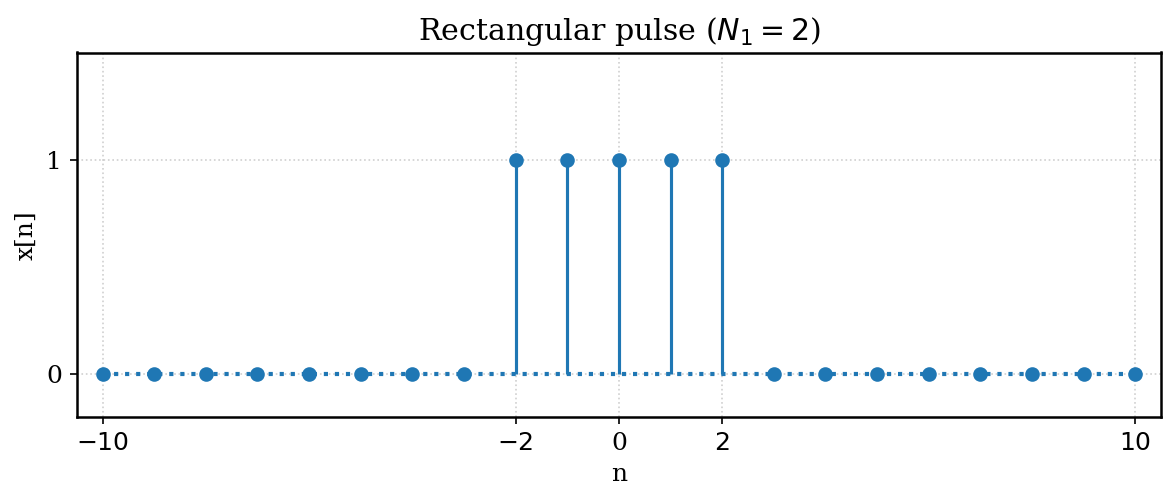


⏺ N₁ = 3
   💾 Saving PNG ...
   ✔️  PNG: plots\rect_n1_3_20260511_145450.png
   💾 Saving SVG ...
   ✔️  SVG: plots\rect_n1_3_20260511_145450.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\rect_n1_3_20260511_145450.emf


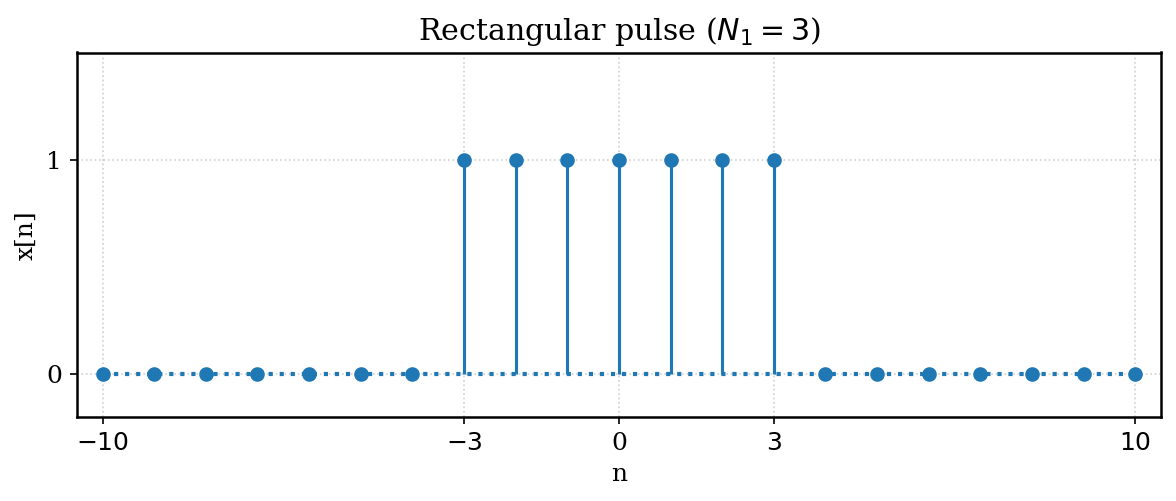


⏺ N₁ = 4
   💾 Saving PNG ...
   ✔️  PNG: plots\rect_n1_4_20260511_145451.png
   💾 Saving SVG ...
   ✔️  SVG: plots\rect_n1_4_20260511_145451.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\rect_n1_4_20260511_145451.emf


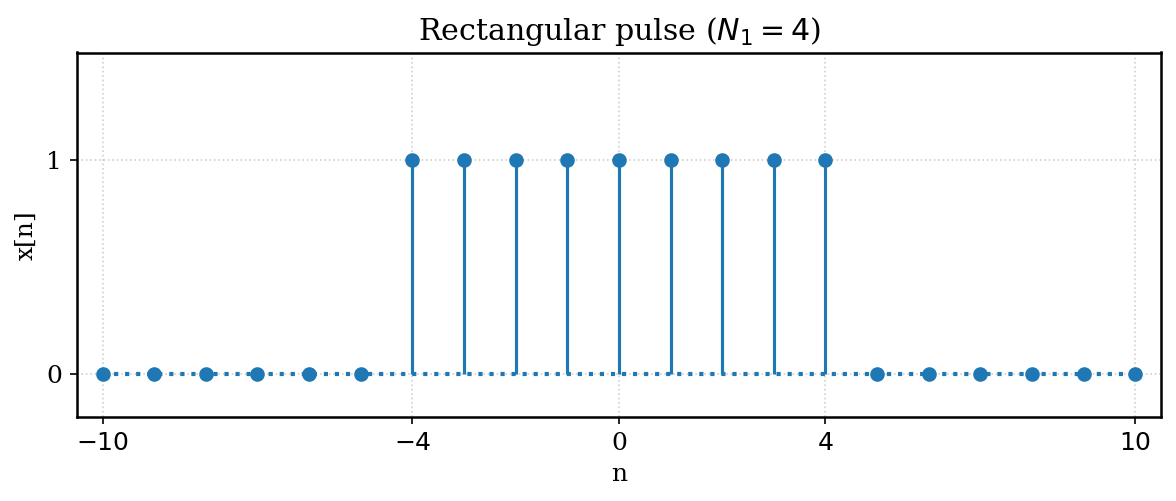


⏺ N₁ = 5
   💾 Saving PNG ...
   ✔️  PNG: plots\rect_n1_5_20260511_145454.png
   💾 Saving SVG ...
   ✔️  SVG: plots\rect_n1_5_20260511_145454.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\rect_n1_5_20260511_145454.emf


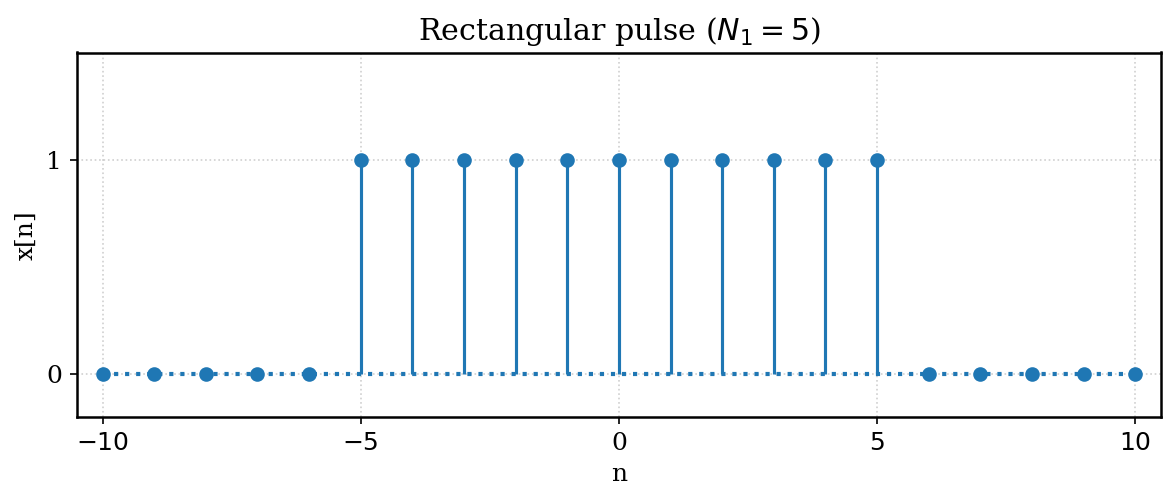


✅ Time‑domain plots done.



In [4]:
print("⏳ Generating time‑domain rectangular pulse plots for each N₁ ...\n")

for N1 in N1_values:
    print(f"⏺ N₁ = {N1}")

    # Full time axis from -10 to 10 
    n_full = np.arange(-10, 11)             
    x_full = np.zeros_like(n_full, dtype=float)

    #   only ones inside the rectangular window [-N1, N1]
    x_full[(n_full >= -N1) & (n_full <= N1)] = 1

    fig_stem, ax_stem = plt.subplots(figsize=(8, 3.5))  
    markerline, stemlines, baseline = ax_stem.stem(n_full, x_full, basefmt=":")
    plt.setp(stemlines, linewidth=1.5, color='#1f77b4')
    plt.setp(markerline, markersize=6, color='#1f77b4')

    ax_stem.set_xlabel('n')
    ax_stem.set_ylabel('x[n]')
    ax_stem.set_title(f'Rectangular pulse ($N_1 = {N1}$)')

    
    ax_stem.set_xticks([-10, -N1, 0, N1, 10])
    ax_stem.set_xticklabels([r'$-10$', f'$-{N1}$', '0', f'${N1}$', r'$10$'])
    ax_stem.set_xlim(-10.5, 10.5)            
    ax_stem.set_yticks([0, 1])
    ax_stem.set_ylim(-0.2, 1.5)
    ax_stem.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem_svg = os.path.join(export_dir, f"rect_n1_{N1}_{ts}.svg")
    stem_png = os.path.join(export_dir, f"rect_n1_{N1}_{ts}.png")
    stem_emf = os.path.join(export_dir, f"rect_n1_{N1}_{ts}.emf")

    print("   💾 Saving PNG ...")
    fig_stem.savefig(stem_png, dpi=300)
    print("   ✔️  PNG:", stem_png)

    print("   💾 Saving SVG ...")
    fig_stem.savefig(stem_svg)
    print("   ✔️  SVG:", stem_svg)

    if ENABLE_EMF_EXPORT:
        print("   🔄 EMF via Inkscape ...")
        try:
            if not os.path.isfile(INKSCAPE_EXE):
                raise FileNotFoundError(f"Inkscape not found at: {INKSCAPE_EXE}")
            cmd = [INKSCAPE_EXE, stem_svg, "--export-type=emf", f"--export-filename={stem_emf}"]
            subprocess.run(cmd, check=True)
            print("   ✔️  EMF:", stem_emf)
        except Exception as e:
            print(f"   [WARN] EMF export failed: {e}")

    plt.show()
    print("")

print("✅ Time‑domain plots done.\n")

Cell 5 – Individual DTFT plot for each N₁

⏳ Generating individual DTFT plots for each N₁ ...

⏺ N₁ = 1
   💾 Saving PNG ...
   ✔️  PNG: plots\dtft_n1_1_20260511_145456.png
   💾 Saving SVG ...
   ✔️  SVG: plots\dtft_n1_1_20260511_145456.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\dtft_n1_1_20260511_145456.emf


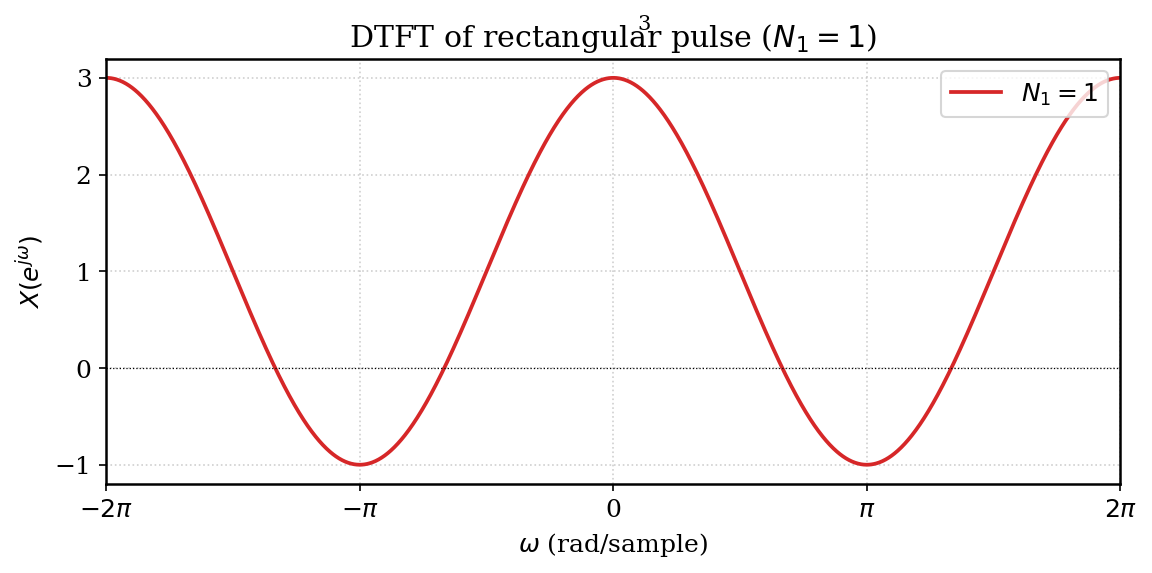


⏺ N₁ = 2
   💾 Saving PNG ...
   ✔️  PNG: plots\dtft_n1_2_20260511_145458.png
   💾 Saving SVG ...
   ✔️  SVG: plots\dtft_n1_2_20260511_145458.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\dtft_n1_2_20260511_145458.emf


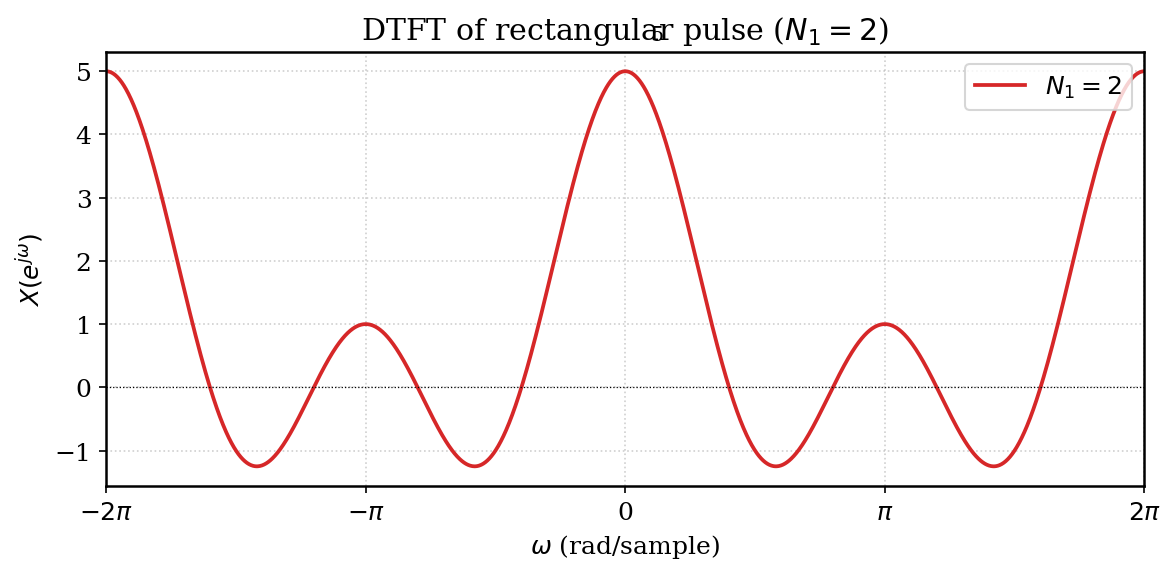


⏺ N₁ = 3
   💾 Saving PNG ...
   ✔️  PNG: plots\dtft_n1_3_20260511_145500.png
   💾 Saving SVG ...
   ✔️  SVG: plots\dtft_n1_3_20260511_145500.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\dtft_n1_3_20260511_145500.emf


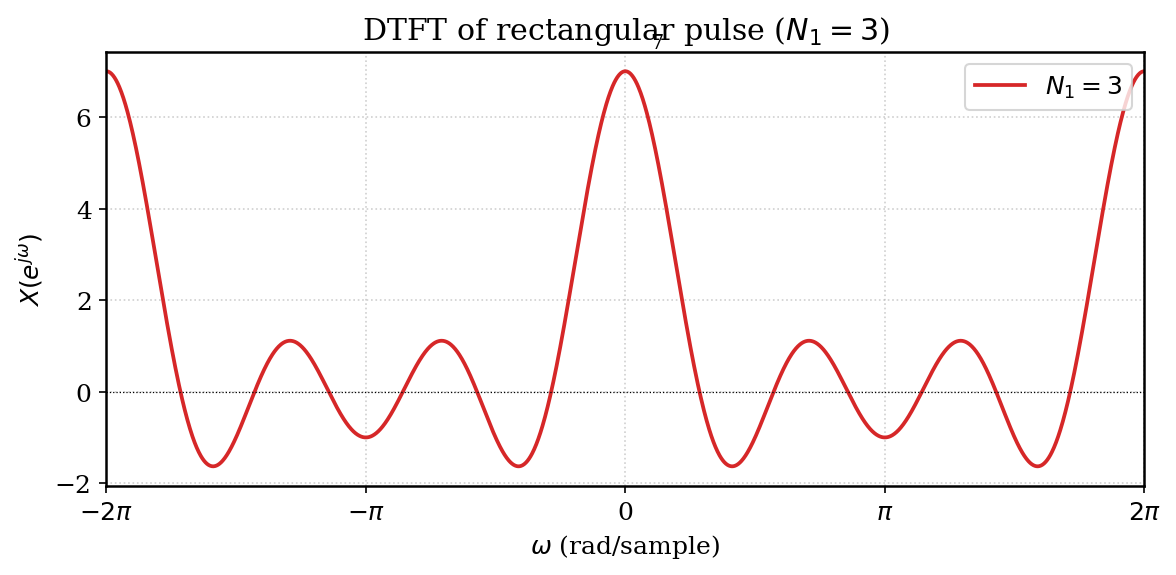


⏺ N₁ = 4
   💾 Saving PNG ...
   ✔️  PNG: plots\dtft_n1_4_20260511_145502.png
   💾 Saving SVG ...
   ✔️  SVG: plots\dtft_n1_4_20260511_145502.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\dtft_n1_4_20260511_145502.emf


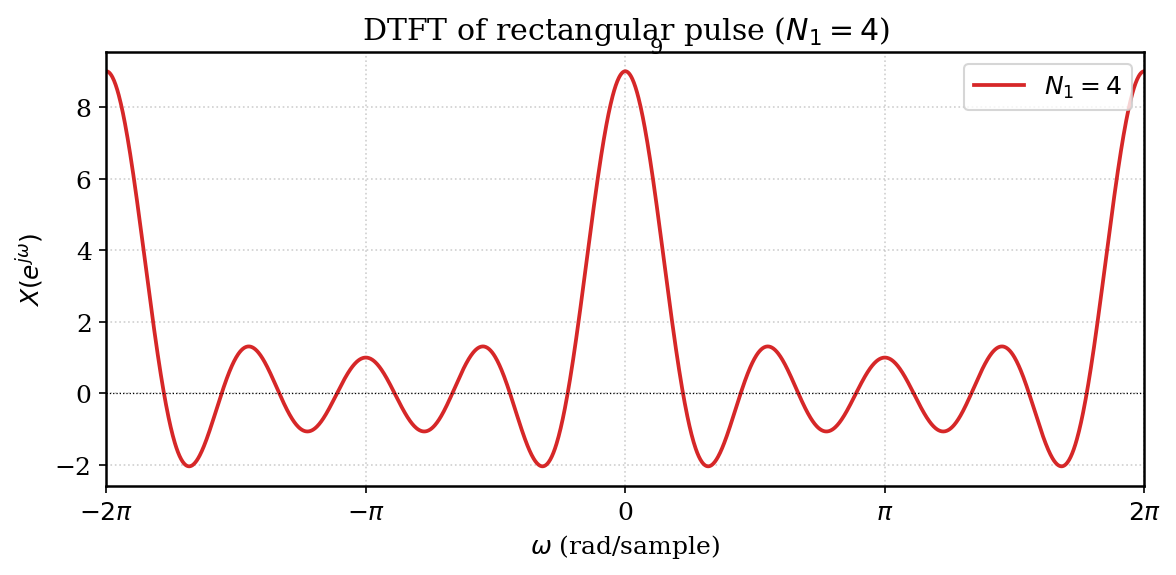


⏺ N₁ = 5
   💾 Saving PNG ...
   ✔️  PNG: plots\dtft_n1_5_20260511_145505.png
   💾 Saving SVG ...
   ✔️  SVG: plots\dtft_n1_5_20260511_145505.svg
   🔄 EMF via Inkscape ...
   ✔️  EMF: plots\dtft_n1_5_20260511_145505.emf


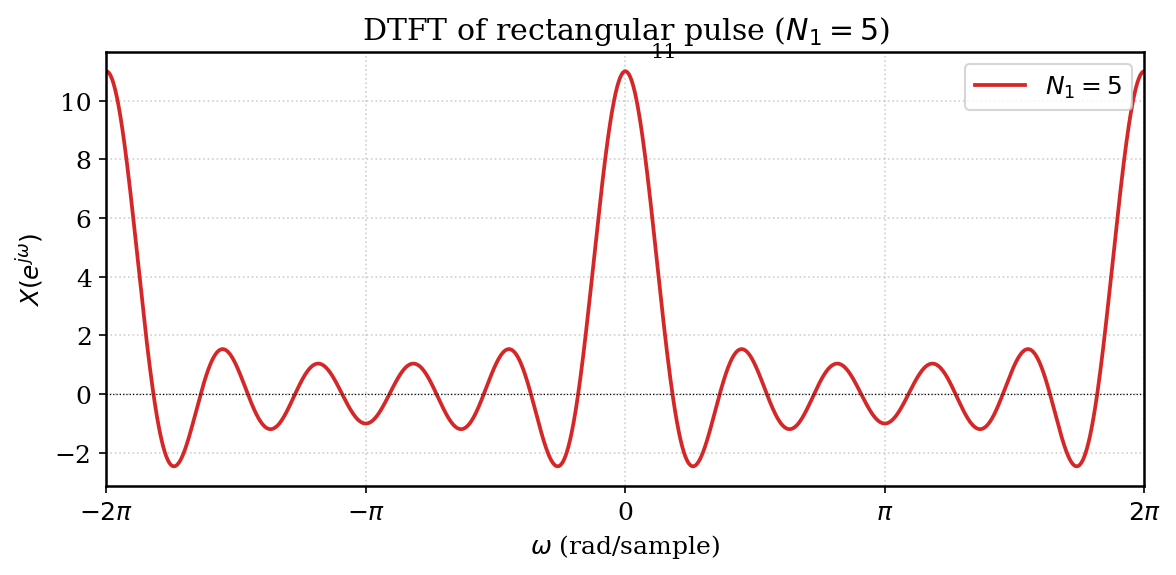


✅ Individual DTFT plots done.

🎉 All tasks completed. Check the plots/ folder for all files.


In [5]:
print("⏳ Generating individual DTFT plots for each N₁ ...\n")

# Frequency range from -2π to 2π 
omega_ind = np.linspace(-2*np.pi, 2*np.pi, 2000)

for N1 in N1_values:
    print(f"⏺ N₁ = {N1}")
    X = dtft_square_pulse(omega_ind, N1)

    fig_ind, ax_ind = plt.subplots(figsize=(8, 4))
    ax_ind.plot(omega_ind, X, color='#d62728', linewidth=1.8, label=f'$N_1 = {N1}$')
    ax_ind.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax_ind.set_xlabel(r'$\omega$ (rad/sample)')
    ax_ind.set_ylabel(r'$X(e^{j\omega})$')
    ax_ind.set_title(f'DTFT of rectangular pulse ($N_1 = {N1}$)')
    ax_ind.legend(loc='upper right')

    
    ax_ind.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
    ax_ind.set_xticklabels([r'$-2\pi$', r'$-\pi$', '0', r'$\pi$', r'$2\pi$'])
    ax_ind.set_xlim(-2*np.pi, 2*np.pi)
    ax_ind.grid(True, linestyle=':', alpha=0.6)

    
    ax_ind.annotate(
        f'{2*N1+1}',
        xy=(0, 2*N1+1),
        xytext=(0.3, 2*N1+1 + 0.5),
        fontsize=10,
        color='black'
    )

    plt.tight_layout()

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    ind_svg = os.path.join(export_dir, f"dtft_n1_{N1}_{ts}.svg")
    ind_png = os.path.join(export_dir, f"dtft_n1_{N1}_{ts}.png")
    ind_emf = os.path.join(export_dir, f"dtft_n1_{N1}_{ts}.emf")

    print("   💾 Saving PNG ...")
    fig_ind.savefig(ind_png, dpi=300)
    print("   ✔️  PNG:", ind_png)

    print("   💾 Saving SVG ...")
    fig_ind.savefig(ind_svg)
    print("   ✔️  SVG:", ind_svg)

    if ENABLE_EMF_EXPORT:
        print("   🔄 EMF via Inkscape ...")
        try:
            if not os.path.isfile(INKSCAPE_EXE):
                raise FileNotFoundError(f"Inkscape not found at: {INKSCAPE_EXE}")
            cmd = [INKSCAPE_EXE, ind_svg, "--export-type=emf", f"--export-filename={ind_emf}"]
            subprocess.run(cmd, check=True)
            print("   ✔️  EMF:", ind_emf)
        except Exception as e:
            print(f"   [WARN] EMF export failed: {e}")

    plt.show()
    print("")

print("✅ Individual DTFT plots done.\n")
print("🎉 All tasks completed. Check the plots/ folder for all files.")


Combined time-domain rectangular pulses for all N₁ 

Generating combined time-domain plot...
PNG: plots\combined_stems_20260511_153221.png
SVG: plots\combined_stems_20260511_153221.svg
EMF: plots\combined_stems_20260511_153221.emf


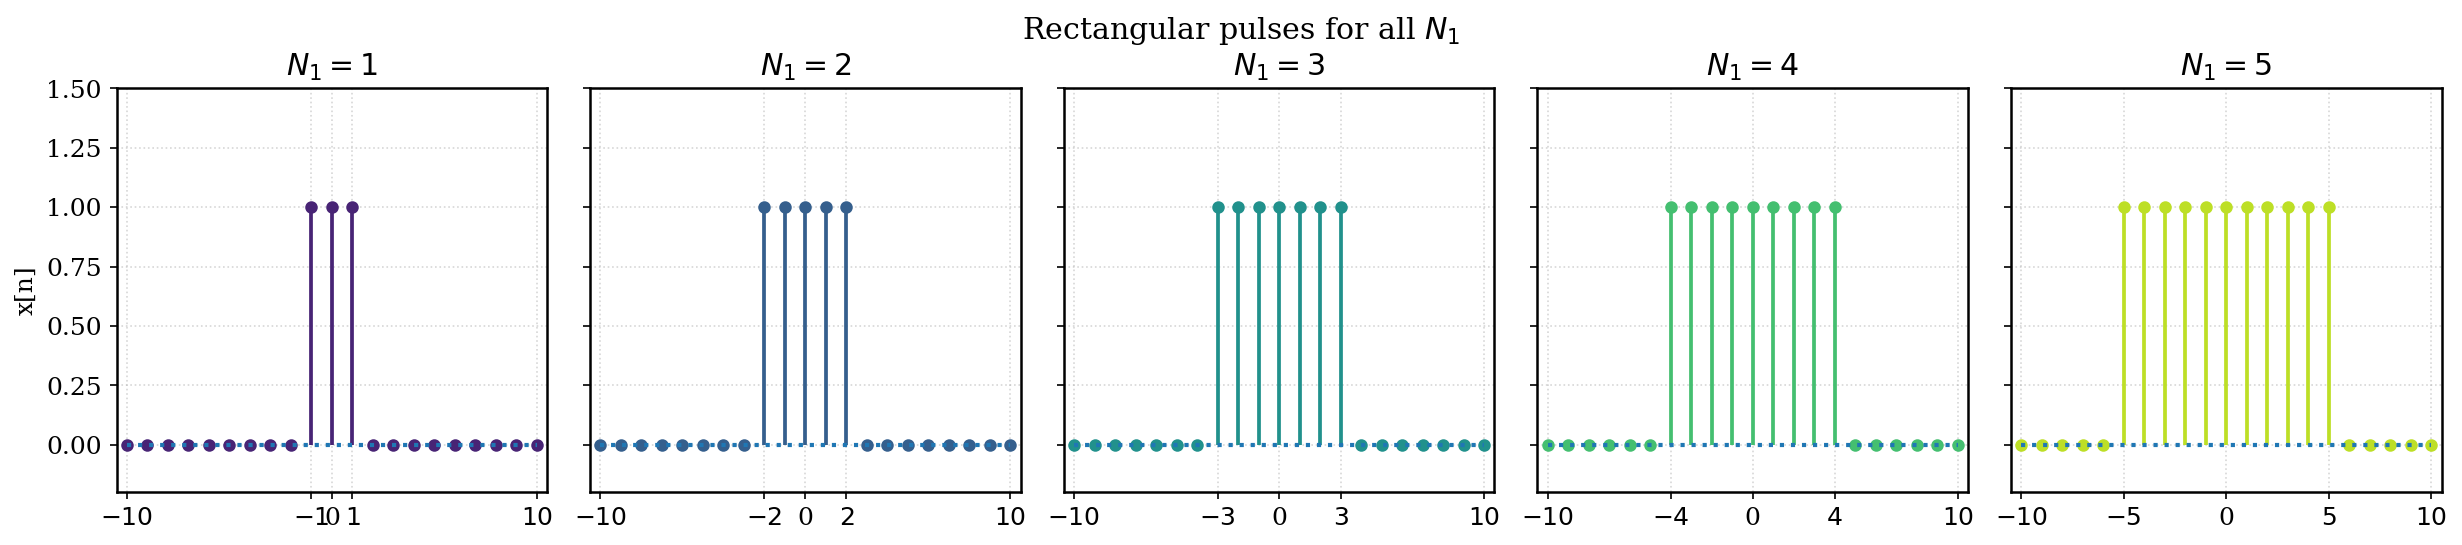

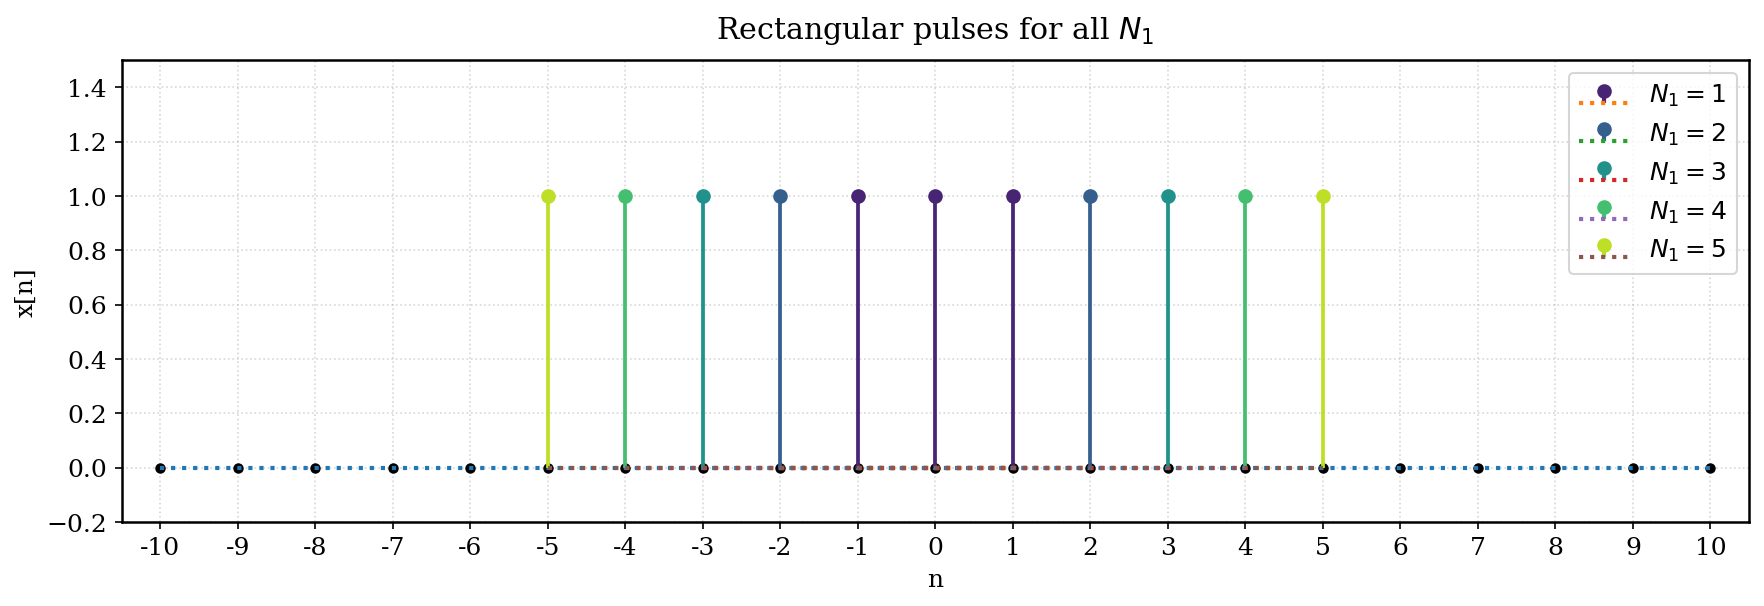

In [ ]:
print("Generating combined time-domain plot...")

fig_stems, axes = plt.subplots(1, len(N1_values), figsize=(4*len(N1_values), 3.5), sharey=True)
fig_stems.subplots_adjust(wspace=0.1)

for idx, (N1, color) in enumerate(zip(N1_values, colors)):
    x_vals = np.zeros_like(n_full, dtype=float)
    x_vals[(n_full >= -N1) & (n_full <= N1)] = 1

    markerline, stemlines, baseline = axes[idx].stem(n_full, x_vals, basefmt=":")
    plt.setp(stemlines, linewidth=1.8, color=color)
    plt.setp(markerline, markersize=5, color=color)

    axes[idx].set_title(f'$N_1 = {N1}$')
    axes[idx].set_xticks([-10, -N1, 0, N1, 10])
    axes[idx].set_xticklabels([r'$-10$', f'$-{N1}$', '0', f'${N1}$', r'$10$'])
    axes[idx].set_xlim(-10.5, 10.5)
    axes[idx].set_ylim(-0.2, 1.5)
    axes[idx].grid(True, linestyle=':', alpha=0.5)

axes[0].set_ylabel('x[n]')
plt.suptitle('Rectangular pulses for all $N_1$', y=1.02)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
svg_f = os.path.join(export_dir, f"combined_stems_{ts}.svg")
png_f = os.path.join(export_dir, f"combined_stems_{ts}.png")
emf_f = os.path.join(export_dir, f"combined_stems_{ts}.emf")

fig_stems.savefig(png_f, dpi=300)
print("PNG:", png_f)
fig_stems.savefig(svg_f)
print("SVG:", svg_f)

if ENABLE_EMF_EXPORT and os.path.isfile(INKSCAPE_EXE):
    subprocess.run([INKSCAPE_EXE, svg_f, "--export-type=emf", f"--export-filename={emf_f}"], check=True)
    print("EMF:", emf_f)

plt.show()


sorted_N1 = sorted(N1_values)
covered = set()
fig_inc, ax_inc = plt.subplots(figsize=(14, 4))

zeros_y = np.zeros_like(n_full, dtype=float)
ml0, sl0, bl0 = ax_inc.stem(n_full, zeros_y, basefmt=":", linefmt='k-', markerfmt='ko')
plt.setp(sl0, linewidth=0.8, color='gray')
plt.setp(ml0, markersize=4, markerfacecolor='black', markeredgecolor='black')

for N1, color in zip(sorted_N1, colors):
    new_n = [n for n in range(-N1, N1+1) if n not in covered]
    if not new_n:
        continue
    covered.update(new_n)
    y_vals = np.ones(len(new_n))
    ml, sl, bl = ax_inc.stem(new_n, y_vals, basefmt=":", label=f'$N_1 = {N1}$')
    plt.setp(sl, color=color, linewidth=1.8)
    plt.setp(ml, color=color, markersize=6)


all_ticks = list(range(-10, 11))
ax_inc.set_xticks(all_ticks)
ax_inc.set_xticklabels([str(i) for i in all_ticks])
ax_inc.set_xlim(-10.5, 10.5)
ax_inc.set_ylim(-0.2, 1.5)
ax_inc.set_xlabel('n')
ax_inc.set_ylabel('x[n]')
ax_inc.set_title('Rectangular pulses for all $N_1$', y=1.02)
ax_inc.legend()
ax_inc.grid(True, linestyle=':', alpha=0.5)

ts3 = datetime.now().strftime("%Y%m%d_%H%M%S")
svg3 = os.path.join(export_dir, f"incremental_stems_{ts3}.svg")
png3 = os.path.join(export_dir, f"incremental_stems_{ts3}.png")
emf3 = os.path.join(export_dir, f"incremental_stems_{ts3}.emf")

fig_inc.savefig(png3, dpi=300)
fig_inc.savefig(svg3)
if ENABLE_EMF_EXPORT and os.path.isfile(INKSCAPE_EXE):
    subprocess.run([INKSCAPE_EXE, svg3, "--export-type=emf", f"--export-filename={emf3}"], check=True)

plt.show()

In [ ]:

sorted_N1 = sorted(N1_values)
fig_ov, ax_ov = plt.subplots(figsize=(14, 4))


zeros_y = np.zeros_like(n_full, dtype=float)
ml0, sl0, bl0 = ax_ov.stem(n_full, zeros_y, basefmt=":", linefmt='k-', markerfmt='ko')
plt.setp(sl0, linewidth=0.8, color='gray')
plt.setp(ml0, markersize=4, markerfacecolor='black', markeredgecolor='black')


for idx, (N1, color) in enumerate(zip(sorted_N1, colors)):
    y_vals = np.zeros_like(n_full, dtype=float)
    y_vals[(n_full >= -N1) & (n_full <= N1)] = 1 + idx * 0.15
    ml, sl, bl = ax_ov.stem(n_full, y_vals, basefmt=":", label=f'$N_1 = {N1}$')
    plt.setp(sl, color=color, linewidth=1.8)
    plt.setp(ml, color=color, markersize=6)

all_ticks = list(range(-10, 11))
ax_ov.set_xticks(all_ticks)
ax_ov.set_xticklabels([str(i) for i in all_ticks])
ax_ov.set_xlim(-10.5, 10.5)
ax_ov.set_xlabel('n')
ax_ov.set_ylabel('x[n] (offset)')
ax_ov.set_title('Rectangular pulses for all $N_1$', y=1.02)
ax_ov.legend()
ax_ov.grid(True, linestyle=':', alpha=0.5)

ts4 = datetime.now().strftime("%Y%m%d_%H%M%S")
svg4 = os.path.join(export_dir, f"overlay_full_pulses_{ts4}.svg")
png4 = os.path.join(export_dir, f"overlay_full_pulses_{ts4}.png")
emf4 = os.path.join(export_dir, f"overlay_full_pulses_{ts4}.emf")
fig_ov.savefig(png4, dpi=300)
fig_ov.savefig(svg4)
if ENABLE_EMF_EXPORT and os.path.isfile(INKSCAPE_EXE):
    subprocess.run([INKSCAPE_EXE, svg4, "--export-type=emf", f"--export-filename={emf4}"], check=True)
plt.show()